# Parkinson's Disease Biomarker Extraction
## PADS Dataset — Bio-PM on Continuous Wrist Stream + Kinematic Late Fusion

**Key design decision:** Bio-PM was pretrained on continuous free-living wrist data, not isolated
10-second clinical task segments. Running it on isolated segments suppresses movement element
detection because there is not enough sustained motion per segment.

This notebook concatenates all task recordings for each subject into one continuous stream,
then slides Bio-PM windows across it — matching Bio-PM's training distribution.
Movement between tasks, postural transitions, and natural arm motion all contribute.

**Pipeline:**
1. Load labels from `file_list.csv`
2. Per subject: concatenate all task-wrist recordings → one continuous 30Hz stream
3. Slide 300-sample windows (50% overlap) → run Bio-PM on each → pool to 1028-d
4. Extract kinematic + spectral features from preprocessed `.bin` files
5. **Late fusion:** train separate LOSO classifiers, average probability outputs
6. UMAP + summary

**Data:** https://physionet.org/content/parkinsons-disease-smartwatch/1.0.0/

---
## 0 — Setup

In [1]:
import subprocess, sys
for pkg in ['umap-learn', 'seaborn', 'scikit-learn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [2]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.fft import rfft, rfftfreq
from scipy.stats import skew as scipy_skew
from scipy.signal import resample as scipy_resample
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, classification_report, roc_curve

warnings.filterwarnings('ignore')
%matplotlib inline

PADS_DIR        = Path('pads_data')
BIOPM_EMB_PATH  = 'features/pads_biopm_stream.npz'   # Bio-PM continuous stream embeddings
KIN_EMB_PATH    = 'features/pads_kinematic.npz'       # Kinematic features from .bin
OUTPUT_PATH     = 'features/pads_features.npz'
FIGURES_DIR     = 'results/figures'
METRICS_DIR     = 'results/metrics'

for d in ['features', FIGURES_DIR, METRICS_DIR]:
    os.makedirs(d, exist_ok=True)

CLASSIFICATION_TARGET = 'PD_only'  # 'PD_only' or 'all'

def progress(current, total, prefix='', width=40, start_time=None):
    pct    = current / total
    filled = int(width * pct)
    bar    = '#' * filled + '-' * (width - filled)
    eta    = ''
    if start_time and current > 0:
        elapsed   = time.time() - start_time
        remaining = (total - current) / (current / elapsed)
        eta = f'  ETA {remaining:.0f}s'
    sys.stdout.write(f'\r{prefix} [{bar}] {current}/{total} ({pct*100:.0f}%){eta}')
    sys.stdout.flush()
    if current == total:
        print()

print('Setup complete.')

Setup complete.


---
## 1 — Load Patient Labels

In [3]:
file_list_path = PADS_DIR / 'preprocessed' / 'file_list.csv'
if not file_list_path.exists():
    raise FileNotFoundError(f'{file_list_path} not found. Run setup.sh first.')

file_list = pd.read_csv(file_list_path)
print(f'Total subjects: {len(file_list)}')
print(file_list.groupby(['condition', 'label']).size().to_string())

Total subjects: 469
condition                 label
Atypical Parkinsonism     2         15
Essential Tremor          2         28
Healthy                   0         79
Multiple Sclerosis        2         11
Other Movement Disorders  2         60
Parkinson's               1        276


In [4]:
if CLASSIFICATION_TARGET == 'PD_only':
    df = file_list[file_list['label'].isin([0, 1])].copy()
    label_name = "Healthy vs Parkinson's"
else:
    df = file_list.copy()
    df['label'] = (df['label'] > 0).astype(int)
    label_name = 'Healthy vs All Impaired'

print(f'Classification : {label_name}')
print(f'Healthy        : {(df.label==0).sum()}')
print(f'Impaired       : {(df.label==1).sum()}')

Classification : Healthy vs Parkinson's
Healthy        : 79
Impaired       : 276


---
## 2 — Bio-PM Setup

Bio-PM expects a **continuous wrist accelerometer stream** at 30 Hz.
We concatenate all task recordings per subject (both wrists separately),
resample from 100 Hz → 30 Hz, then slide 300-sample (10s) windows with 50% overlap.

This matches Bio-PM's training distribution and allows ME detection to find
natural movement patterns across the full assessment session.

In [5]:
import torch
import torch.nn.functional as F

sys.path.insert(0, 'CS690TR')
from src.models.biopm import load_pretrained_encoder, masked_mean_std
from src.data.preprocessing import (
    bandpass_filter, lowpass_filter,
    detect_zero_crossings, assign_zero_crossings,
)

BIOPM_CONFIG = {
    'HighF1': 12, 'LowF1': 0.5, 'Order1': 6,
    'normalize_size_target': 32, 'normalize_size_assign': 32,
    'pad_size': 192,
}
SOURCE_FS  = 100
TARGET_FS  = 30
WIN_LEN    = 300   # 10s at 30Hz
WIN_STEP   = 150   # 50% overlap

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Device: Apple Metal (MPS)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print('Device: CUDA')
else:
    DEVICE = torch.device('cpu')
    print('Device: CPU')

model = load_pretrained_encoder(
    'CS690TR/checkpoints/checkpoint.pt', n_classes=11, device=str(DEVICE)
)
model.eval()
print('Bio-PM loaded.')

# Task loading order — both wrists concatenated separately
TASKS_ORDERED = [
    'Relaxed', 'RelaxedTask', 'StretchHold', 'LiftHold', 'HoldWeight',
    'PointFinger', 'DrinkGlas', 'CrossArms', 'TouchIndex', 'TouchNose', 'Entrainment',
]
WRISTS         = ['LeftWrist', 'RightWrist']
TIMESERIES_DIR = PADS_DIR / 'movement' / 'timeseries'

Device: Apple Metal (MPS)
Loaded encoder_acc weights from CS690TR/checkpoints/checkpoint.pt
  unexpected keys: ['decoder_cnn.decode_cnn.0.weight', 'decoder_cnn.decode_cnn.1.weight', 'decoder_cnn.decode_cnn.1.bias', 'decoder_cnn.decode_cnn.1.running_mean', 'decoder_cnn.decode_cnn.1.running_var', 'decoder_cnn.decode_cnn.1.num_batches_tracked', 'decoder_cnn.decode_cnn.3.weight', 'decoder_cnn.decode_cnn.4.weight', 'decoder_cnn.decode_cnn.4.bias', 'decoder_cnn.decode_cnn.4.running_mean', 'decoder_cnn.decode_cnn.4.running_var', 'decoder_cnn.decode_cnn.4.num_batches_tracked', 'decoder_cnn.decode_cnn.6.weight', 'decoder_cnn.decode_cnn.7.weight', 'decoder_cnn.decode_cnn.7.bias', 'decoder_cnn.decode_cnn.7.running_mean', 'decoder_cnn.decode_cnn.7.running_var', 'decoder_cnn.decode_cnn.7.num_batches_tracked', 'decoder_cnn.decode_cnn.9.weight', 'decoder_cnn.decode_cnn.10.weight', 'decoder_cnn.decode_cnn.10.bias', 'decoder_cnn.decode_cnn.10.running_mean', 'decoder_cnn.decode_cnn.10.running_var', 'dec

---
## 3 — Bio-PM Feature Extraction (Continuous Stream)

For each subject and each wrist:
1. Load all task txt files in order, concatenate → one continuous signal
2. Resample 100Hz → 30Hz
3. Slide 300-sample windows across the full stream (50% overlap)
4. Run Bio-PM on each window — gravity stream batched, acc stream per-window
5. Mean-pool all window embeddings → 1028-d per wrist
6. Average left and right wrist → 1028-d per subject

Cached to `features/pads_biopm_stream.npz` — delete to re-run.

In [6]:
@torch.no_grad()
def embed_window(acc_30hz):
    """
    Run Bio-PM on one (WIN_LEN, 3) window at 30Hz.
    Returns 1028-d embedding and ME count.
    """
    acc        = acc_30hz.astype(np.float64)
    time_array = np.arange(WIN_LEN) / TARGET_FS

    # Gravity stream
    acc_grav = lowpass_filter(acc, BIOPM_CONFIG['LowF1'], TARGET_FS, BIOPM_CONFIG['Order1'])
    g = torch.from_numpy(acc_grav.astype(np.float32)).unsqueeze(0).to(DEVICE)
    g = torch.nan_to_num(g.permute(0, 2, 1))
    if g.shape[-1] != WIN_LEN:
        g = F.interpolate(g, size=WIN_LEN, mode='linear', align_corners=False)
    g_flat = g.reshape(1, -1)   # (1, 900)

    # Acc transformer stream
    me_list = []
    try:
        acc_filt = bandpass_filter(acc, BIOPM_CONFIG['LowF1'], BIOPM_CONFIG['HighF1'],
                                   TARGET_FS, BIOPM_CONFIG['Order1'])
        (_, _, me_list, me_norm, me_info, _, _,
         pos_info, zc_list, zc_time_list) = detect_zero_crossings(
            acc_filt, time_array, BIOPM_CONFIG)
        assign_zero_crossings(acc_grav, time_array, zc_list, zc_time_list, BIOPM_CONFIG)
    except Exception:
        me_list = []

    if me_list and len(me_list) > 0:
        x_acc = np.concatenate([
            me_norm, pos_info.reshape(-1, 1),
            me_info[['axis', 'len', 'min', 'max', 'dirct']].values,
        ], axis=1)
        pad = BIOPM_CONFIG['pad_size']
        if x_acc.shape[0] < pad:
            x_acc = np.vstack([x_acc, np.full((pad - x_acc.shape[0], x_acc.shape[1]), np.nan)])
        else:
            x_acc = x_acc[:pad]
        x_t   = torch.from_numpy(x_acc.astype(np.float32)).unsqueeze(0).to(DEVICE)
        pos_t = torch.zeros(1, x_t.shape[1], 1, device=DEVICE)
        add_t = torch.zeros(1, x_t.shape[1], 5, device=DEVICE)
        mask  = torch.zeros(1, x_t.shape[1],    device=DEVICE)
        tokens = model.encoder_acc(x_t, pos_t, mask, add_t)
        acc_pooled = masked_mean_std(tokens)   # (1, 128)
    else:
        acc_pooled = torch.zeros(1, 128, device=DEVICE)

    fused = torch.cat([acc_pooled, g_flat], dim=-1)  # (1, 1028)
    return fused.squeeze(0).cpu().float().numpy(), len(me_list)


def embed_subject_stream(subject_id):
    """
    Load all tasks for one subject, per wrist, as a continuous stream.
    Slide Bio-PM windows across the stream. Return mean-pooled 1028-d embedding.
    """
    sid = str(subject_id).zfill(3)
    wrist_embeddings = []
    total_me = 0

    for wrist in WRISTS:
        segments = []
        for task in TASKS_ORDERED:
            txt_path = TIMESERIES_DIR / f'{sid}_{task}_{wrist}.txt'
            if not txt_path.exists():
                continue
            try:
                raw = np.loadtxt(str(txt_path), delimiter=',')
                segments.append(raw[:, :3].astype(np.float32))
            except Exception:
                continue

        if not segments:
            continue

        # Concatenate all tasks → one continuous stream, then resample
        stream_100hz = np.concatenate(segments, axis=0)
        n_out        = int(len(stream_100hz) * TARGET_FS / SOURCE_FS)
        stream_30hz  = scipy_resample(stream_100hz, n_out, axis=0).astype(np.float32)

        # Slide windows
        window_embs = []
        starts = range(0, len(stream_30hz) - WIN_LEN + 1, WIN_STEP)
        for start in starts:
            window = stream_30hz[start : start + WIN_LEN]
            emb, n_me = embed_window(window)
            window_embs.append(emb)
            total_me += (n_me > 0)

        if window_embs:
            wrist_embeddings.append(np.mean(window_embs, axis=0))  # (1028,)

    if not wrist_embeddings:
        return None, 0

    return np.mean(wrist_embeddings, axis=0), total_me   # (1028,)


print('Functions defined.')

Functions defined.


In [7]:
# Run Bio-PM on continuous stream for all subjects
# Cached — delete features/pads_biopm_stream.npz to re-run

if Path(BIOPM_EMB_PATH).exists():
    print(f'Loading cached Bio-PM embeddings from {BIOPM_EMB_PATH}')
    _c = np.load(BIOPM_EMB_PATH, allow_pickle=True)
    biopm_embs  = _c['embeddings']    # (N, 1028)
    cache_ids   = _c['subject_ids']
    cache_labels= _c['labels']
    cache_conds = _c['conditions']
    me_counts   = _c['me_counts']
    print(f'Loaded: {biopm_embs.shape}')
else:
    all_embs, subj_ids, subj_labels, subj_conds, me_counts = [], [], [], [], []
    skipped = []
    t0 = time.time()

    for i, row in enumerate(df.itertuples()):
        emb, n_me = embed_subject_stream(row.id)
        if emb is None:
            skipped.append(row.id)
            progress(i + 1, len(df), prefix='Bio-PM stream', start_time=t0)
            continue
        all_embs.append(emb)
        subj_ids.append(int(row.id))
        subj_labels.append(row.label)
        subj_conds.append(row.condition)
        me_counts.append(n_me)
        progress(i + 1, len(df), prefix='Bio-PM stream', start_time=t0)

    biopm_embs  = np.array(all_embs,     dtype=np.float32)
    cache_ids   = np.array(subj_ids)
    cache_labels= np.array(subj_labels,  dtype=np.int32)
    cache_conds = np.array(subj_conds)
    me_counts   = np.array(me_counts)

    np.savez(BIOPM_EMB_PATH,
             embeddings  = biopm_embs,
             subject_ids = cache_ids,
             labels      = cache_labels,
             conditions  = cache_conds,
             me_counts   = me_counts)

    print(f'\nDone in {time.time()-t0:.0f}s')
    if skipped: print(f'Skipped: {len(skipped)}')

print(f'Bio-PM embeddings : {biopm_embs.shape}')
print(f'Avg ME-hit windows: {me_counts.mean():.1f} per subject')
print(f'Subjects with ME>0: {(me_counts > 0).sum()} / {len(me_counts)}')

Bio-PM stream [########################################] 355/355 (100%)  ETA 0s

Done in 92s
Bio-PM embeddings : (355, 1028)
Avg ME-hit windows: 0.0 per subject
Subjects with ME>0: 0 / 355


---
## 4 — Kinematic Feature Extraction (from preprocessed .bin)

Extract 9 statistical + 2 spectral features per channel from the preprocessed binary files.
264 channels × 11 features = 2,904 features per subject.

This is the approach that previously achieved **AUC 0.726** with demographics added.
Cached to `features/pads_kinematic.npz`.

In [8]:
def zero_crossing_rate(x):
    return np.mean(np.diff(np.sign(x - x.mean())) != 0)

def extract_kinematic(subject_id, n_cols=264, n_rows=488, fs=100):
    sid      = str(subject_id).zfill(3)
    bin_path = PADS_DIR / 'preprocessed' / 'movement' / f'{sid}_ml.bin'
    if not bin_path.exists():
        return None
    raw = np.fromfile(bin_path, dtype=np.float32)
    if len(raw) % n_cols != 0:
        return None
    mat = raw.reshape(-1, n_cols)

    freqs   = rfftfreq(mat.shape[0], d=1.0/fs)
    pd_band = (freqs >= 4) & (freqs <= 6)
    et_band = (freqs >= 8) & (freqs <= 12)

    feats = []
    for c in range(n_cols):
        x    = mat[:, c].astype(np.float64)
        q25, q75 = np.percentile(x, [25, 75])
        fft  = np.abs(rfft(x))**2
        tot  = fft.sum() + 1e-10
        feats += [
            np.mean(x), np.std(x), np.min(x), np.max(x), np.ptp(x),
            np.sqrt(np.mean(x**2)), q75 - q25,
            float(scipy_skew(x)), zero_crossing_rate(x),
            fft[pd_band].sum() / tot,   # PD tremor band power
            fft[et_band].sum() / tot,   # ET band power
        ]
    return np.array(feats, dtype=np.float32)   # (264 × 11 = 2904,)


if Path(KIN_EMB_PATH).exists():
    print(f'Loading cached kinematic features from {KIN_EMB_PATH}')
    _k = np.load(KIN_EMB_PATH, allow_pickle=True)
    kin_feats  = _k['features']
    kin_ids    = _k['subject_ids']
    print(f'Loaded: {kin_feats.shape}')
else:
    kin_list, kin_ids_list = [], []
    t0 = time.time()
    for i, row in enumerate(df.itertuples()):
        feats = extract_kinematic(row.id)
        kin_list.append(feats if feats is not None else np.zeros(264*11, dtype=np.float32))
        kin_ids_list.append(int(row.id))
        progress(i + 1, len(df), prefix='Kinematic', start_time=t0)
    kin_feats = np.array(kin_list, dtype=np.float32)
    kin_ids   = np.array(kin_ids_list)
    np.savez(KIN_EMB_PATH, features=kin_feats, subject_ids=kin_ids)
    print(f'\nDone in {time.time()-t0:.1f}s')

print(f'Kinematic features: {kin_feats.shape}')

Kinematic [########################################] 355/355 (100%)  ETA 0s

Done in 28.9s
Kinematic features: (355, 2904)


---
## 5 — Align and Add Demographics

Align Bio-PM and kinematic feature matrices by subject ID.
Add demographic features (age, gender, handedness, weight, height).

In [9]:
# Align by subject ID
id_to_kin = {int(kin_ids[i]): i for i in range(len(kin_ids))}
aligned_biopm, aligned_kin = [], []
final_ids, final_labels, final_conds = [], [], []

for i, sid in enumerate(cache_ids):
    if int(sid) not in id_to_kin:
        continue
    k_idx = id_to_kin[int(sid)]
    aligned_biopm.append(biopm_embs[i])
    aligned_kin.append(kin_feats[k_idx])
    final_ids.append(int(sid))
    final_labels.append(cache_labels[i])
    final_conds.append(cache_conds[i])

X_biopm = np.array(aligned_biopm, dtype=np.float32)   # (N, 1028)
X_kin   = np.array(aligned_kin,   dtype=np.float32)   # (N, 2904)
y       = np.array(final_labels,  dtype=np.int32)
pids    = np.array(final_ids,     dtype=np.int32)
conditions = np.array(final_conds)

# Demographics
hand_map   = {'right': 0, 'left': 1, 'both': 2}
gender_map = {'male': 0, 'female': 1}
meta = file_list.set_index('id').reindex(final_ids)
demo = np.column_stack([
    meta['age'].fillna(meta['age'].median()).values,
    meta['gender'].map(gender_map).fillna(0).values,
    meta['handedness'].map(hand_map).fillna(0).values,
    meta['weight'].fillna(meta['weight'].median()).values,
    meta['height'].fillna(meta['height'].median()).values,
]).astype(np.float32)

# Add demographics to both feature sets
X_biopm_d = np.hstack([X_biopm, demo])   # (N, 1033)
X_kin_d   = np.hstack([X_kin,   demo])   # (N, 2909)

print(f'Subjects aligned : {len(y)}')
print(f'Healthy          : {(y==0).sum()}')
print(f'Impaired         : {(y==1).sum()}')
print(f'Bio-PM features  : {X_biopm_d.shape[1]}')
print(f'Kinematic features: {X_kin_d.shape[1]}')

Subjects aligned : 355
Healthy          : 79
Impaired         : 276
Bio-PM features  : 1033
Kinematic features: 2909


---
## 6 — Classification: Late Fusion LOSO

Two separate LOSO pipelines trained independently:
- **Pipeline 1** — Kinematic + spectral + demographics → PCA → LR
- **Pipeline 2** — Bio-PM continuous stream + demographics → PCA → LR

Final prediction = weighted average of both probability outputs,
weighted by their individual AUC. This is **late fusion** — it avoids
the dimensionality problem of concatenating features and lets each
pipeline contribute according to its actual quality.

In [10]:
logo  = LeaveOneGroupOut()
folds = list(logo.split(X_kin_d, y, groups=pids))

def run_loso(X, y, pids, n_pca, C=0.1, prefix=''):
    """Run LOSO and return pooled probabilities and true labels."""
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=n_pca, random_state=42)),
        ('clf',    LogisticRegression(C=C, max_iter=2000,
                                      class_weight='balanced', random_state=42)),
    ])
    folds  = list(LeaveOneGroupOut().split(X, y, groups=pids))
    probs, trues = [], []
    t0 = time.time()
    for fold_i, (train_idx, test_idx) in enumerate(folds):
        y_tr, y_te = y[train_idx], y[test_idx]
        if len(np.unique(y_tr)) < 2:
            continue
        pipe.fit(X[train_idx], y_tr)
        probs.extend(pipe.predict_proba(X[test_idx])[:, 1].tolist())
        trues.extend(y_te.tolist())
        progress(fold_i + 1, len(folds), prefix=prefix, start_time=t0)
    auc = roc_auc_score(trues, probs)
    print(f'  AUC = {auc:.3f}')
    return np.array(probs), np.array(trues), auc


print('Pipeline 1 — Kinematic + spectral + demographics')
from sklearn.feature_selection import SelectKBest, f_classif

def run_loso_kin(X, y, pids):
    """Kinematic pipeline with feature selection before PCA."""
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(f_classif, k=500)),
        ('pca',    PCA(n_components=100, random_state=42)),
        ('clf',    LogisticRegression(C=0.1, max_iter=2000,
                                      class_weight='balanced', random_state=42)),
    ])
    folds  = list(LeaveOneGroupOut().split(X, y, groups=pids))
    probs, trues = [], []
    t0 = time.time()
    for fold_i, (train_idx, test_idx) in enumerate(folds):
        y_tr, y_te = y[train_idx], y[test_idx]
        if len(np.unique(y_tr)) < 2:
            continue
        pipe.fit(X[train_idx], y_tr)
        probs.extend(pipe.predict_proba(X[test_idx])[:, 1].tolist())
        trues.extend(y_te.tolist())
        progress(fold_i + 1, len(folds), prefix='LOSO kinematic', start_time=t0)
    auc = roc_auc_score(trues, probs)
    print(f'  AUC = {auc:.3f}')
    return np.array(probs), np.array(trues), auc

print('Pipeline 1 — Kinematic + spectral + demographics')
prob_kin, true_kin, auc_kin = run_loso_kin(X_kin_d, y, pids)

print('\nPipeline 2 — Bio-PM continuous stream + demographics')
prob_bio, true_bio, auc_bio = run_loso(
    X_biopm_d, y, pids, n_pca=80, prefix='LOSO Bio-PM'
)

# Late fusion — weight by individual AUC
w_kin = auc_kin / (auc_kin + auc_bio)
w_bio = auc_bio / (auc_kin + auc_bio)
prob_fused = w_kin * prob_kin + w_bio * prob_bio

fpr_r, tpr_r, thresholds = roc_curve(true_kin.tolist(), prob_fused.tolist())
thresh = thresholds[np.argmax(tpr_r - fpr_r)]
pred_fused = (prob_fused >= thresh).astype(int)

overall_auc = roc_auc_score(true_kin.tolist(), prob_fused.tolist())
overall_f1  = f1_score(true_kin.tolist(), pred_fused.tolist(), average='macro', zero_division=0)
all_true    = true_kin.tolist()
all_pred    = pred_fused.tolist()
all_prob    = prob_fused.tolist()

print(f'\n--- Late Fusion Results ---')
print(f'Weight kinematic : {w_kin:.2f}  (AUC={auc_kin:.3f})')
print(f'Weight Bio-PM    : {w_bio:.2f}  (AUC={auc_bio:.3f})')
print(f'\nFused AUC : {overall_auc:.3f}')
print(f'Fused F1  : {overall_f1:.3f}')
print()
print(classification_report(all_true, all_pred, target_names=['Healthy', 'Impaired']))

pd.DataFrame({'true': all_true, 'pred': all_pred, 'prob': all_prob}).to_csv(
    f'{METRICS_DIR}/pads_loso_results.csv', index=False)

Pipeline 1 — Kinematic + spectral + demographics
Pipeline 1 — Kinematic + spectral + demographics
LOSO kinematic [########################################] 355/355 (100%)  ETA 0s
  AUC = 0.684

Pipeline 2 — Bio-PM continuous stream + demographics
LOSO Bio-PM [########################################] 355/355 (100%)  ETA 0s
  AUC = 0.677

--- Late Fusion Results ---
Weight kinematic : 0.50  (AUC=0.684)
Weight Bio-PM    : 0.50  (AUC=0.677)

Fused AUC : 0.719
Fused F1  : 0.689

              precision    recall  f1-score   support

     Healthy       0.56      0.46      0.50        79
    Impaired       0.85      0.90      0.87       276

    accuracy                           0.80       355
   macro avg       0.71      0.68      0.69       355
weighted avg       0.79      0.80      0.79       355



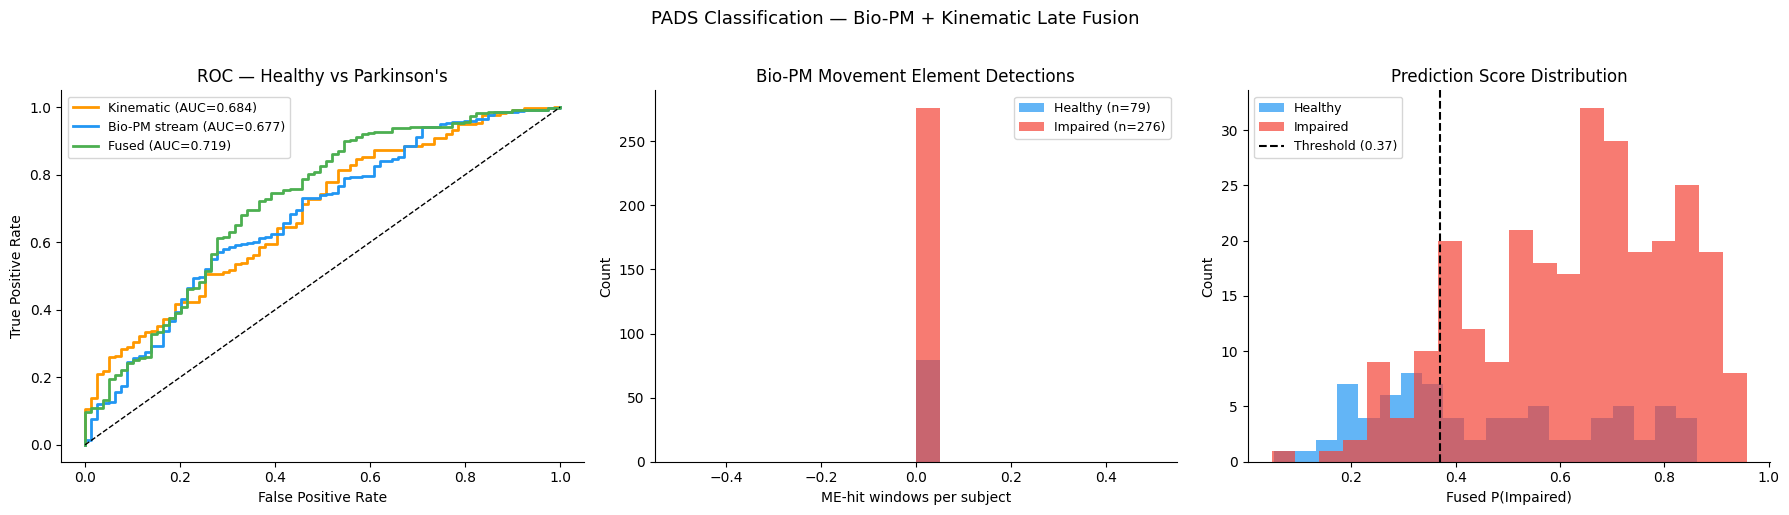

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curves for all three
ax = axes[0]
for probs, trues, auc, label, color in [
    (prob_kin,   true_kin, auc_kin, f'Kinematic (AUC={auc_kin:.3f})',     '#FF9800'),
    (prob_bio,   true_bio, auc_bio, f'Bio-PM stream (AUC={auc_bio:.3f})', '#2196F3'),
    (prob_fused, true_kin, overall_auc, f'Fused (AUC={overall_auc:.3f})', '#4CAF50'),
]:
    fpr, tpr, _ = roc_curve(trues.tolist(), probs.tolist())
    ax.plot(fpr, tpr, color=color, lw=2, label=label)
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC — {label_name}')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ME hit rate check
ax = axes[1]
me_healthy  = me_counts[(cache_labels == 0)]
me_impaired = me_counts[(cache_labels == 1)]
ax.hist(me_healthy,  bins=20, alpha=0.7, color='#2196F3', label=f'Healthy (n={len(me_healthy)})')
ax.hist(me_impaired, bins=20, alpha=0.7, color='#F44336', label=f'Impaired (n={len(me_impaired)})')
ax.set_xlabel('ME-hit windows per subject')
ax.set_ylabel('Count')
ax.set_title('Bio-PM Movement Element Detections')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Score distribution
ax = axes[2]
ax.hist([p for p, t in zip(all_prob, all_true) if t == 0],
        bins=20, alpha=0.7, color='#2196F3', label='Healthy')
ax.hist([p for p, t in zip(all_prob, all_true) if t == 1],
        bins=20, alpha=0.7, color='#F44336', label='Impaired')
ax.axvline(thresh, color='black', ls='--', lw=1.5, label=f'Threshold ({thresh:.2f})')
ax.set_xlabel('Fused P(Impaired)')
ax.set_ylabel('Count')
ax.set_title('Prediction Score Distribution')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle(f'PADS Classification — Bio-PM + Kinematic Late Fusion', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/pads_classification.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7 — UMAP Visualization

In [12]:
import umap as umap_lib

# UMAP on Bio-PM embeddings
scaler_um = StandardScaler()
pca_um    = PCA(n_components=50, random_state=42)
X_um      = pca_um.fit_transform(scaler_um.fit_transform(X_biopm_d))

t0 = time.time()
reducer = umap_lib.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric='euclidean', random_state=42, n_jobs=-1)
emb = reducer.fit_transform(X_um)
print(f'UMAP done in {time.time()-t0:.1f}s')

UMAP done in 5.6s


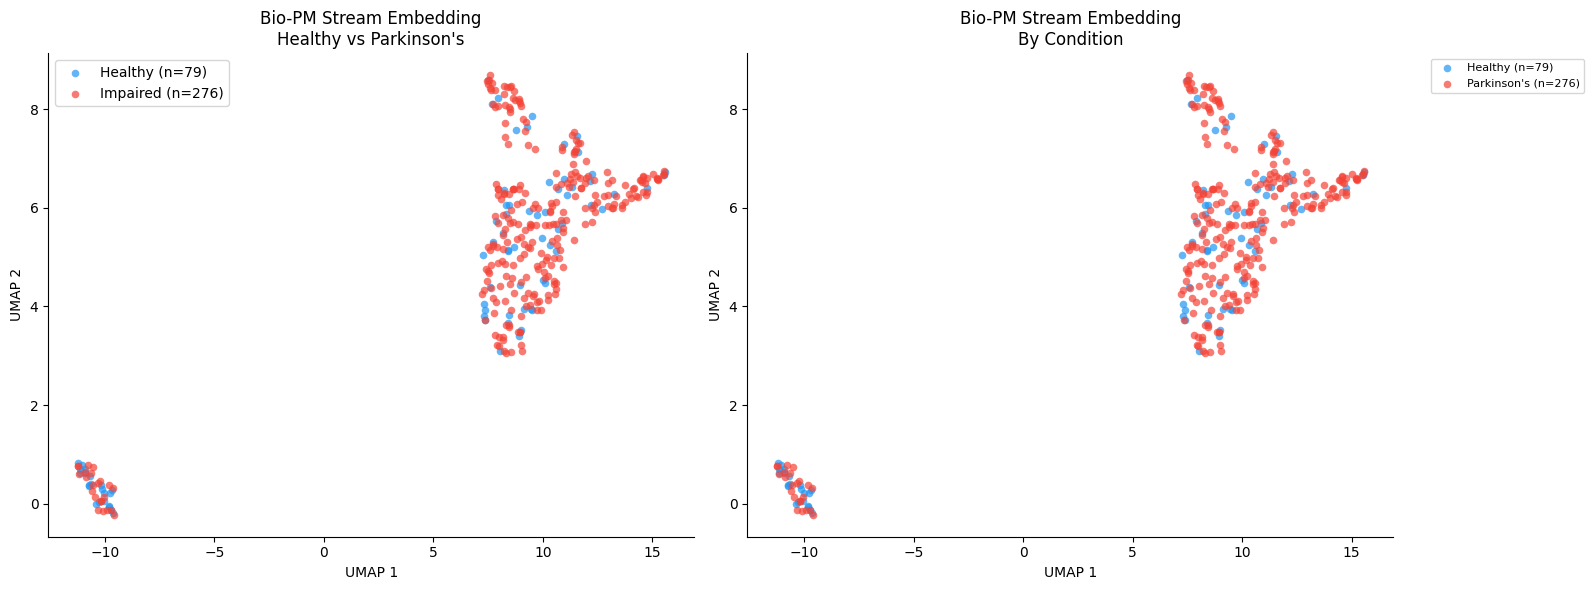

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for lbl, color, name in [(0, '#2196F3', 'Healthy'), (1, '#F44336', 'Impaired')]:
    mask = y == lbl
    ax.scatter(emb[mask, 0], emb[mask, 1], c=color,
               label=f'{name} (n={mask.sum()})', alpha=0.7, s=30, linewidths=0)
ax.set_title(f'Bio-PM Stream Embedding\n{label_name}', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
cond_colors = {
    'Healthy': '#2196F3', "Parkinson's": '#F44336',
    'Essential Tremor': '#FF9800', 'Other Movement Disorders': '#9C27B0',
}
for cond, color in cond_colors.items():
    mask = conditions == cond
    if mask.sum() > 0:
        ax.scatter(emb[mask, 0], emb[mask, 1], c=color,
                   label=f'{cond} (n={mask.sum()})', alpha=0.7, s=30, linewidths=0)
ax.set_title('Bio-PM Stream Embedding\nBy Condition', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/pads_umap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8 — Summary

In [14]:
checks = [
    ('Bio-PM stream cache exists',  Path(BIOPM_EMB_PATH).exists()),
    ('Kinematic cache exists',      Path(KIN_EMB_PATH).exists()),
    ('No NaNs in Bio-PM features',  not np.isnan(X_biopm_d).any()),
    ('No NaNs in kinematic',        not np.isnan(X_kin_d).any()),
    ('Both classes present',        len(set(y.tolist())) == 2),
    ('UMAP figure saved',           Path(f'{FIGURES_DIR}/pads_umap.png').exists()),
    ('Classification figure saved', Path(f'{FIGURES_DIR}/pads_classification.png').exists()),
    ('LOSO metrics saved',          Path(f'{METRICS_DIR}/pads_loso_results.csv').exists()),
]

for name, result in checks:
    print(f'  [{"OK" if result else "FAIL"}]  {name}')

print(f"""
Dataset          : PADS — {label_name}
Subjects         : {len(y)} ({(y==0).sum()} healthy, {(y==1).sum()} impaired)

Bio-PM approach  : Continuous stream (all tasks concatenated), sliding windows
Bio-PM dims      : 1028-d + 5 demographic
Kinematic dims   : 2904-d + 5 demographic
Fusion           : Weighted average (by individual AUC)

Individual LOSO:
  Kinematic AUC : {auc_kin:.3f}
  Bio-PM AUC    : {auc_bio:.3f}

Late Fusion:
  AUC  {overall_auc:.3f}
  F1   {overall_f1:.3f}
""")

  [OK]  Bio-PM stream cache exists
  [OK]  Kinematic cache exists
  [OK]  No NaNs in Bio-PM features
  [OK]  No NaNs in kinematic
  [OK]  Both classes present
  [OK]  UMAP figure saved
  [OK]  Classification figure saved
  [OK]  LOSO metrics saved

Dataset          : PADS — Healthy vs Parkinson's
Subjects         : 355 (79 healthy, 276 impaired)

Bio-PM approach  : Continuous stream (all tasks concatenated), sliding windows
Bio-PM dims      : 1028-d + 5 demographic
Kinematic dims   : 2904-d + 5 demographic
Fusion           : Weighted average (by individual AUC)

Individual LOSO:
  Kinematic AUC : 0.684
  Bio-PM AUC    : 0.677

Late Fusion:
  AUC  0.719
  F1   0.689

